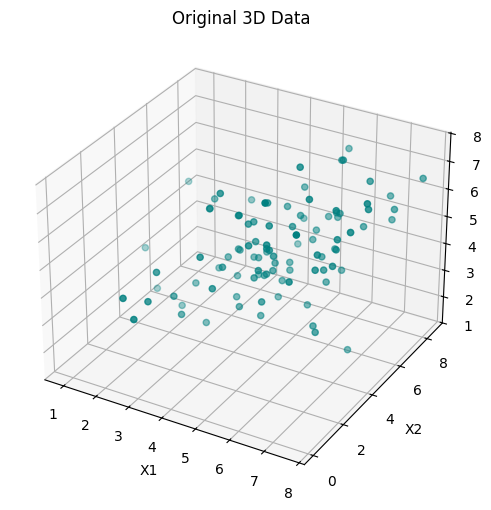

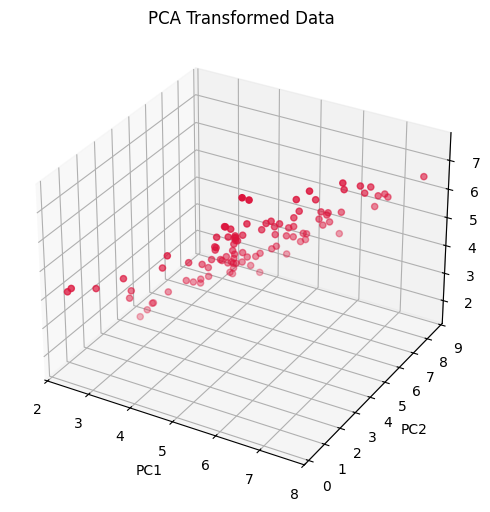

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA

# Generate a random 3D dataset with correlation
np.random.seed(42)
n_samples = 100
X = np.random.multivariate_normal([5, 5, 5], [[3, 2, 1], [2, 3, 1], [1, 1, 2]], n_samples)

# Apply PCA to reduce 3D data to 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Create a function to animate the 3D scatter plot
def animate_3D(i, scatter, ax):
    ax.view_init(elev=20, azim=i)
    return scatter,

# Create figure for original 3D data
fig1 = plt.figure(figsize=(6, 6))
ax1 = fig1.add_subplot(111, projection='3d')
scatter1 = ax1.scatter(X[:, 0], X[:, 1], X[:, 2], c='teal', s=20)
ax1.set_title("Original 3D Data")
ax1.set_xlabel("X1")
ax1.set_ylabel("X2")
ax1.set_zlabel("X3")
ani1 = animation.FuncAnimation(fig1, animate_3D, frames=360, interval=20, fargs=(scatter1, ax1))

# Reconstruct the PCA components into 3D space for visualization
X_pca_3D = pca.inverse_transform(X_pca)

# Create figure for transformed 3D data
fig2 = plt.figure(figsize=(6, 6))
ax2 = fig2.add_subplot(111, projection='3d')
scatter2 = ax2.scatter(X_pca_3D[:, 0], X_pca_3D[:, 1], X_pca_3D[:, 2], c='crimson', s=20)
ax2.set_title("PCA Transformed Data")
ax2.set_xlabel("PC1")
ax2.set_ylabel("PC2")
ax2.set_zlabel("PC3")
ani2 = animation.FuncAnimation(fig2, animate_3D, frames=360, interval=20, fargs=(scatter2, ax2))

plt.show()


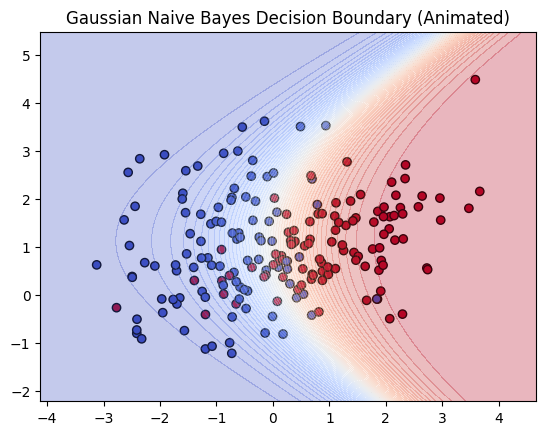

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from sklearn.naive_bayes import GaussianNB
from sklearn.datasets import make_classification
from matplotlib.colors import ListedColormap

# Generate sample 2D classification data
X, y = make_classification(n_samples=200, n_features=2, n_redundant=0,
                           n_clusters_per_class=1, n_classes=2, random_state=42)

# Train Gaussian Naive Bayes model
gnb = GaussianNB()
gnb.fit(X, y)

# Setup meshgrid for decision surface
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

# Prepare figure
fig, ax = plt.subplots()
scatter = ax.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolor='k')
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.set_title('Gaussian Naive Bayes Decision Boundary (Animated)')

Z = gnb.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1].reshape(xx.shape)
levels = np.linspace(0, 1, 50)
contour = ax.contourf(xx, yy, Z, levels=levels, alpha=0.3, cmap='coolwarm')

# Animation function
def update(frame):
    ax.clear()
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_title(f'Decision Boundary - Frame {frame+1}')
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolor='k')

    # Simulate progressive learning by increasing number of training samples
    if frame == 0:
        partial_X = X[:10]
        partial_y = y[:10]
    else:
        partial_X = X[:10 + frame*10]
        partial_y = y[:10 + frame*10]

    temp_model = GaussianNB()
    temp_model.fit(partial_X, partial_y)

    Z = temp_model.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1].reshape(xx.shape)
    contour = ax.contourf(xx, yy, Z, levels=levels, alpha=0.3, cmap='coolwarm')
    return contour.collections

# Create animation
anim = FuncAnimation(fig, update, frames=10, interval=800, blit=False)

plt.show()
